# Mini-Proyecto: Detección de Spam en SMS con Embeddings y LSTM

> **Caso propio basado en los notebooks 3 (*Embeddings y LSTM mínimo*) y 4 (*LSTM avanzado con PyTorch Lightning*) de la Sesión 1.**
>
> A diferencia de los ejemplos guía (clasificación de noticias en español), aquí abordamos un problema **binario** de **detección de spam en mensajes SMS** usando el dataset público `ucirvine/sms_spam`.

---

## Planteamiento del Problema

El **spam SMS** — mensajes no deseados de naturaleza publicitaria, fraudulenta o engañosa — sigue siendo un vector de ataque común en plataformas móviles. Clasificadores tradicionales (reglas basadas en palabras clave, Naive Bayes sobre TF-IDF) tienen dificultades con:

- Mensajes cortos con jerga coloquial (*"U wan 2 win?"*).
- Ofuscación de URLs y números de teléfono.
- Sarcasmo o redacción creativa para evadir filtros.
- Desbalance entre clases (la mayoría son *ham*).

**¿Por qué una propuesta basada en *embeddings + LSTM* es adecuada?**

1. Los **word embeddings** capturan similitud semántica (e.g., *"free"*, *"win"*, *"claim"* se acercan en el espacio vectorial), incluso para términos que no aparecen literalmente en reglas.
2. Las **LSTM** procesan la secuencia completa del mensaje capturando dependencias locales (*"FREE — for the FIRST 100 people"*) mejor que un modelo bag-of-words.
3. Podemos comparar el desempeño con un **baseline clásico** (TF-IDF + Regresión Logística) y justificar la ganancia de la solución neuronal.

---

## Referencias

- Dataset: https://huggingface.co/datasets/ucirvine/sms_spam
- Paper original: *Almeida, T.A., Gomez Hidalgo, J.M., Yamakami, A. (2011). Contributions to the Study of SMS Spam Filtering: New Collection and Results. ACM DOCENG'11.*
- [Word Vectors and spaCy Similarity](https://spacy.io/usage/linguistic-features#vectors-similarity)
- [Long Short-Term Memory (Hochreiter & Schmidhuber, 1997)](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory)
- [PyTorch Lightning Docs](https://lightning.ai/docs/pytorch/stable/)

---


## 1. Preparación del entorno

El notebook está diseñado para ejecutarse tanto en **Colab** como en local. Detectamos el entorno y cargamos dependencias en consecuencia.


In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")


Running in Colab: True


In [2]:
# Instalación reproducible para Google Colab.
# Colab ya incluye PyTorch; instalamos solo las dependencias del notebook.
import subprocess
import sys
from pathlib import Path

packages = [
    'datasets', 'lightning', 'torchmetrics', 'spacy', 'scipy',
    'scikit-learn', 'seaborn', 'tqdm', 'tensorboard'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_md'])

CHECKPOINT_PATH = Path.cwd() / 'best_simple_lstm.pt'
print(f'Checkpoint: {CHECKPOINT_PATH}')

Checkpoint: /content/best_simple_lstm.pt


In [3]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")


Dispositivo: cuda


## 2. Carga del dataset y Análisis Exploratorio (EDA)

Cargamos el dataset de Hugging Face y analizamos su estructura, distribución de clases y patrones lingüísticos.


In [4]:
from datasets import load_dataset

dataset = load_dataset('ucirvine/sms_spam', split='train')
dataset


README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

Dataset({
    features: ['sms', 'label'],
    num_rows: 5574
})

In [5]:
df = dataset.to_pandas()
df.columns = ['sms', 'label']
df['label_name'] = df['label'].map({0: 'ham', 1: 'spam'})
print(f"Total mensajes: {len(df)}")
print(f"Forma: {df.shape}")
df.head(10)


Total mensajes: 5574
Forma: (5574, 3)


,sms,label,label_name
0,"Go until jurong point, crazy.. Available only ...",0,ham
1,Ok lar... Joking wif u oni...\n,0,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,spam
3,U dun say so early hor... U c already then say...,0,ham
4,"Nah I don't think he goes to usf, he lives aro...",0,ham
5,FreeMsg Hey there darling it's been 3 week's n...,1,spam
6,Even my brother is not like to speak with me. ...,0,ham
7,As per your request 'Melle Melle (Oru Minnamin...,0,ham
8,WINNER!! As a valued network customer you have...,1,spam
9,Had your mobile 11 months or more? U R entitle...,1,spam


### 2.1 Distribución de clases
Es crucial detectar desbalance, ya que afecta tanto la función de pérdida como la elección de métricas (no basta con accuracy).


label_name
ham     4827
spam     747
Name: count, dtype: int64

Spam ratio: 13.40%


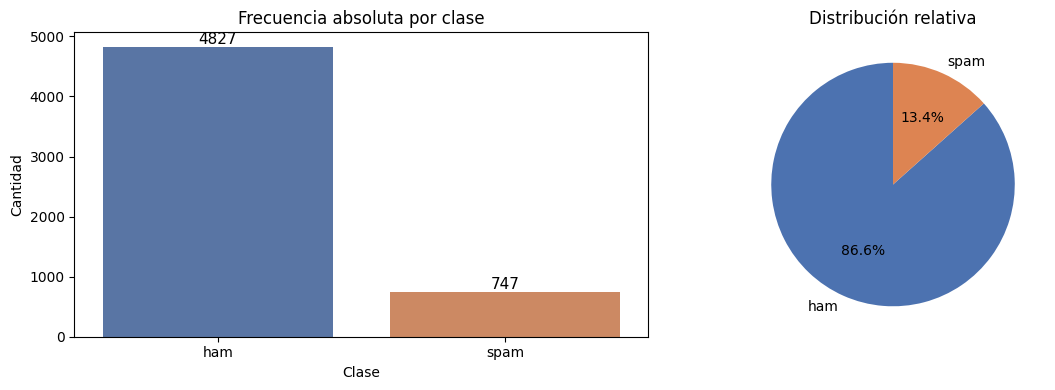

In [6]:
class_counts = df['label_name'].value_counts()
print(class_counts)
print(f"\nSpam ratio: {class_counts['spam'] / len(df):.2%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='label_name', data=df, palette=['#4C72B0', '#DD8452'], ax=ax[0])
ax[0].set_title('Frecuencia absoluta por clase')
ax[0].set_xlabel('Clase')
ax[0].set_ylabel('Cantidad')
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=11)

class_counts.plot.pie(autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], ax=ax[1], startangle=90)
ax[1].set_ylabel('')
ax[1].set_title('Distribución relativa')
plt.tight_layout()
plt.show()


### 2.2 Longitud de los mensajes
¿Los spam son sistemáticamente más largos o más cortos? ¿Usan más tokens?


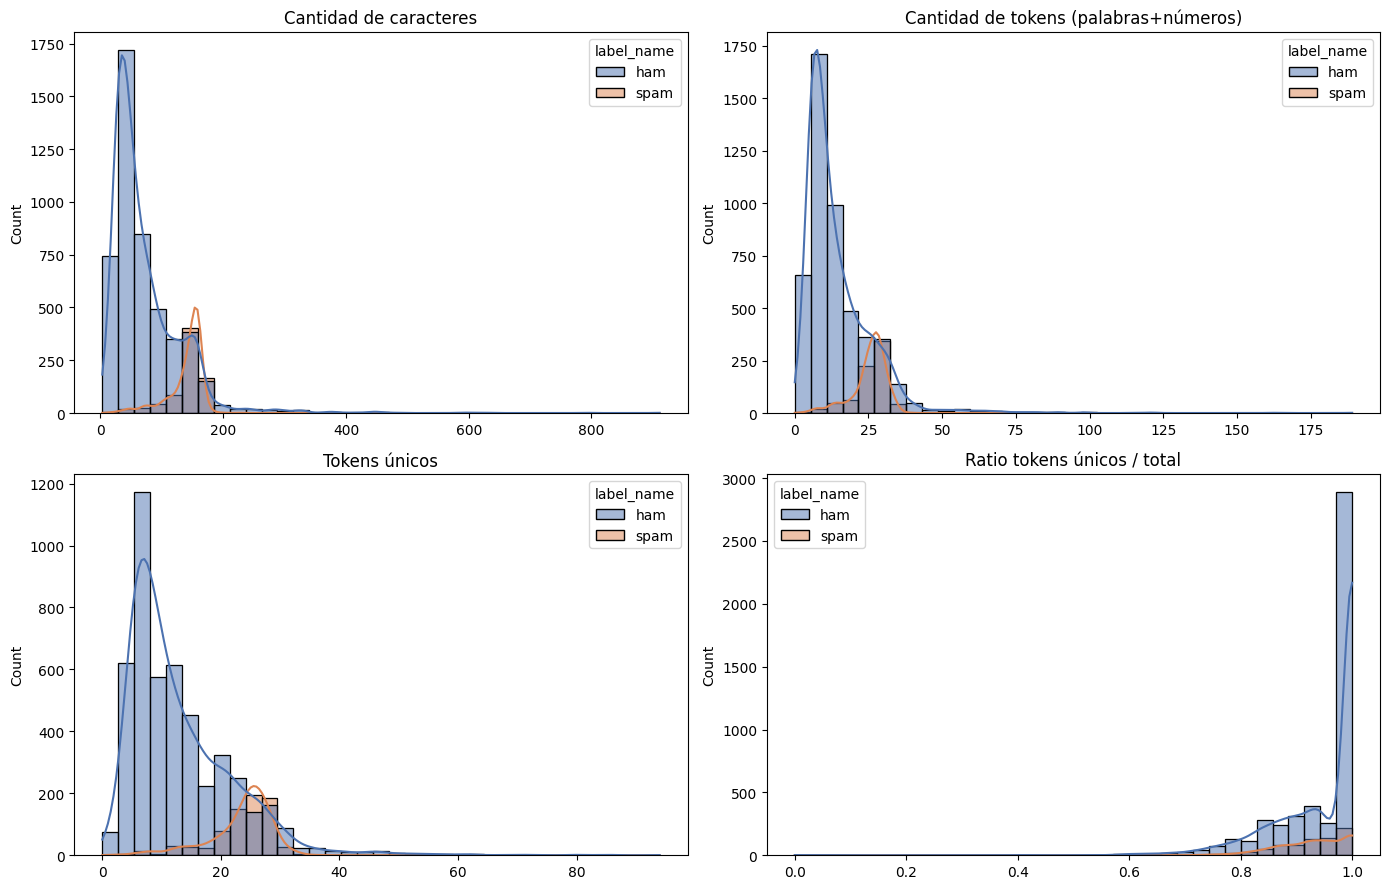

label_name                 ham    spam
n_chars         count  4827.00  747.00
                mean     72.47  139.68
                std      58.33   28.87
                min       3.00   14.00
                25%      34.00  134.00
                50%      53.00  150.00
                75%      94.00  158.00
                max     911.00  224.00
n_tokens        count  4827.00  747.00
                mean     14.42   25.33
                std      11.60    5.87
                min       0.00    2.00
                25%       7.00   24.00
                50%      11.00   27.00
                75%      19.00   29.00
                max     189.00   39.00
n_unique_tokens count  4827.00  747.00
                mean     13.07   23.49
                std       8.95    5.27
                min       0.00    2.00
                25%       7.00   22.00
                50%      10.00   25.00
                75%      17.00   27.00
                max      94.00   36.00
ratio_unique    count  4827.00  747.00
                mean      0.95    0.93
                std       0.08    0.06
                min       0.00    0.67
                25%       0.91    0.89
                50%       1.00    0.94
                75%       1.00    1.00
                max       1.00    1.00

In [7]:
import re

def simple_tokenize(text: str):
    return re.findall(r"[a-zA-Z0-9']+", text.lower())

df['n_chars'] = df['sms'].str.len()
df['n_tokens'] = df['sms'].apply(lambda x: len(simple_tokenize(x)))
df['n_unique_tokens'] = df['sms'].apply(lambda x: len(set(simple_tokenize(x))))
df['ratio_unique'] = df['n_unique_tokens'] / (df['n_tokens'] + 1e-6)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [('n_chars', 'Cantidad de caracteres'),
           ('n_tokens', 'Cantidad de tokens (palabras+números)'),
           ('n_unique_tokens', 'Tokens únicos'),
           ('ratio_unique', 'Ratio tokens únicos / total')]

for ax, (col, title) in zip(axes.flatten(), metrics):
    sns.histplot(data=df, x=col, hue='label_name', kde=True, bins=35,
                 palette=['#4C72B0', '#DD8452'], ax=ax, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

df.groupby('label_name')[['n_chars', 'n_tokens', 'n_unique_tokens', 'ratio_unique']].describe().T.round(2)


### 2.3 Huellas digitales del spam (feature engineering heurístico)
Antes de llegar a embeddings, comprobamos si existen patrones *superficiales* que ya separen clases:
- Presencia de **URLs** o dominios abreviados.
- Presencia de **números de teléfono** largos (cadenas de ≥6 dígitos).
- Presencia de símbolos monetarios (£, €, $) — el dataset es de origen UK.
- Uso abusivo de **MAYÚSCULAS**.


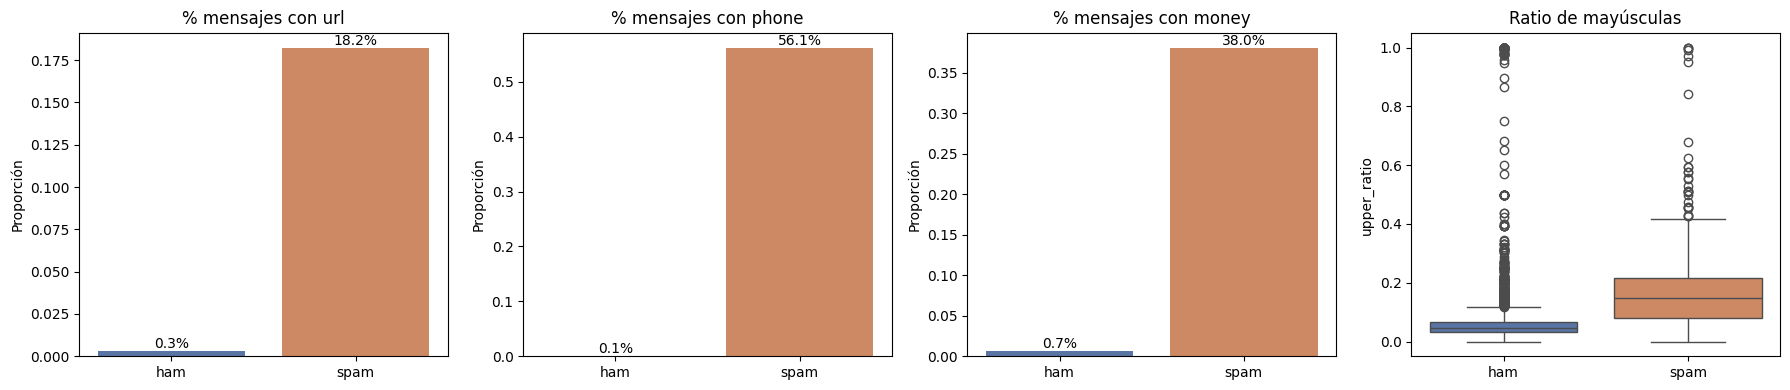

label_name,ham,spam
has_url,0.29%,18.21%
has_phone,0.06%,56.09%
has_money,0.66%,38.02%
upper_ratio,7.90%,16.73%


In [8]:
def has_url(text: str) -> int:
    return int(bool(re.search(r'(https?://|www\.|\b\w+\.co\.|\.com\b|\.uk\b)', text, re.I)))

def has_long_digits(text: str) -> int:
    return int(bool(re.search(r'\d{6,}', text)))

def has_money(text: str) -> int:
    return int(bool(re.search(r'[£€$¥]|\bpound|\beuro|\bdollar', text, re.I)))

def uppercase_ratio(text: str) -> float:
    letters = [c for c in text if c.isalpha()]
    return sum(c.isupper() for c in letters) / (len(letters) + 1e-6)

df['has_url'] = df['sms'].apply(has_url)
df['has_phone'] = df['sms'].apply(has_long_digits)
df['has_money'] = df['sms'].apply(has_money)
df['upper_ratio'] = df['sms'].apply(uppercase_ratio)

heuristics = ['has_url', 'has_phone', 'has_money', 'upper_ratio']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, heuristics):
    if feat.startswith('has_'):
        sns.barplot(x='label_name', y=feat, data=df, palette=['#4C72B0', '#DD8452'], ax=ax, errorbar=None)
        ax.set_title(f'% mensajes con {feat.replace("has_","")}')
        ax.set_ylabel('Proporción')
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1%}', (p.get_x()+p.get_width()/2., p.get_height()),
                        ha='center', va='bottom')
    else:
        sns.boxplot(x='label_name', y=feat, data=df, palette=['#4C72B0', '#DD8452'], ax=ax)
        ax.set_title('Ratio de mayúsculas')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

display(df.groupby('label_name')[heuristics].mean().T.style.format('{:.2%}'))


### 2.4 Palabras más frecuentes y N-gramas
¿Qué términos dominan cada clase?


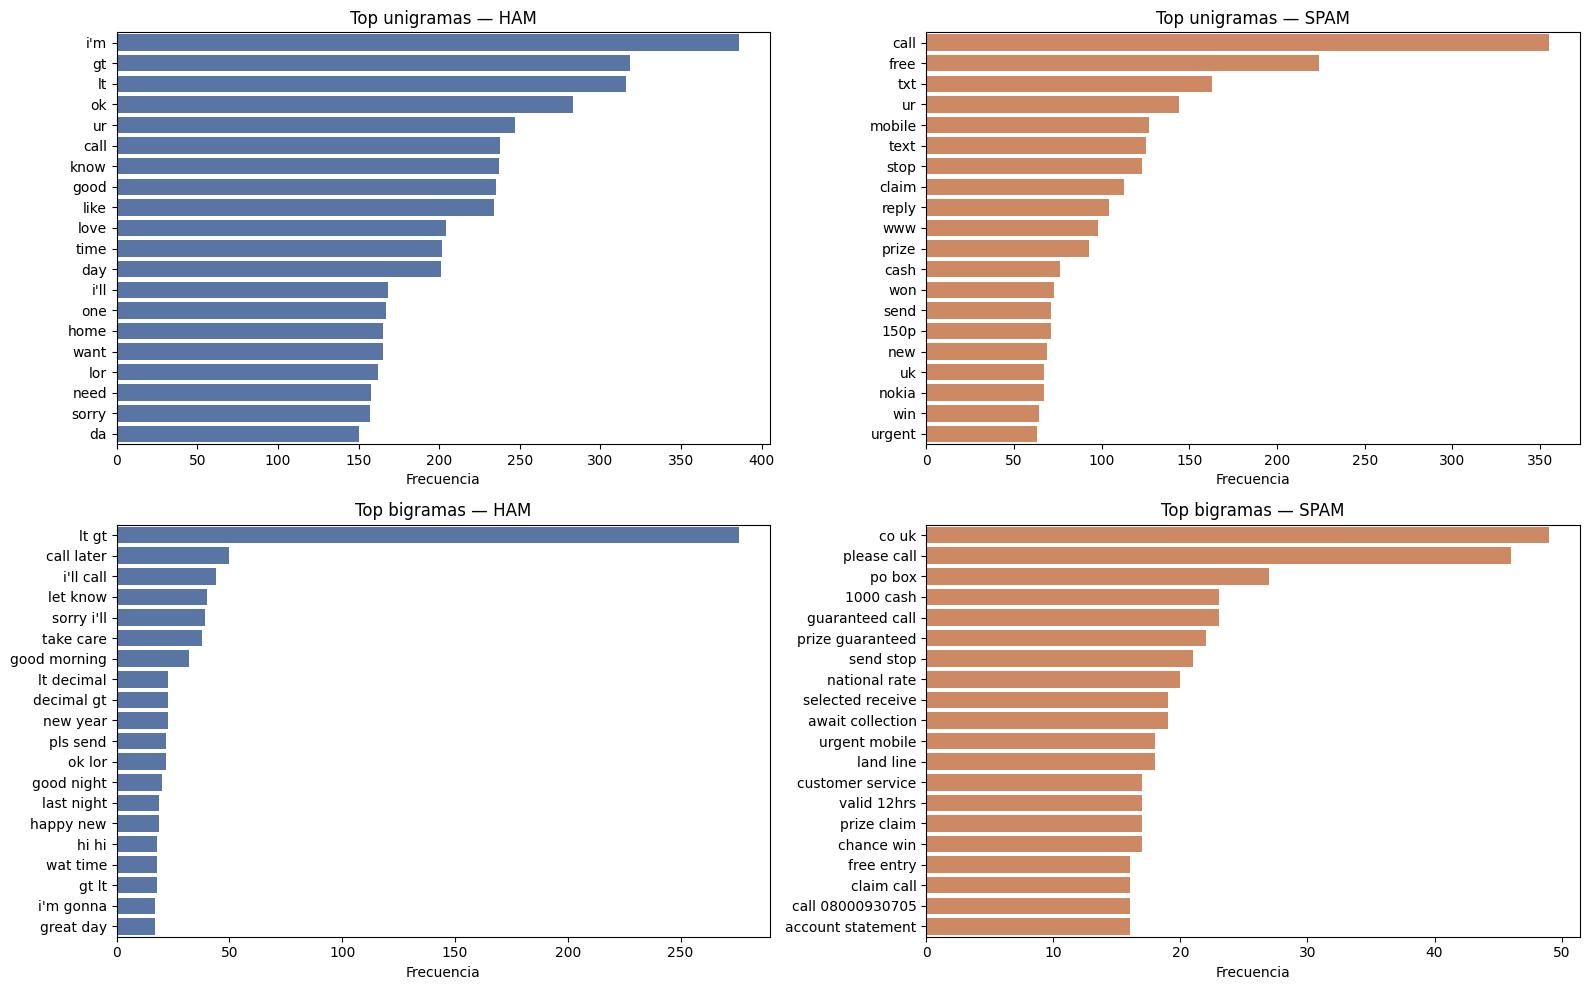

In [9]:
from collections import Counter

STOPWORDS = set(['a', 'an', 'the', 'and', 'or', 'but', 'if', 'then', 'else', 'to', 'of', 'in', 'on', 'at', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'can', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'its', 'our', 'their', 'this', 'that', 'these', 'those', 'so', 'not', 'no', 'as', 'for', 'with', 'by', 'from', 'about', 'up', 'out', 'just', 'also', 'too', 'very', 's', 't', 'd', 'll', 'm', 're', 've', 'am', 'than', 'then', 'now', 'get', 'got', 'go', 'going', 'come', 'coming', 'back', 'still', 'even', 'only', 'over', 'again', 'how', 'what', 'when', 'where', 'who', 'why', 'which', 'there', 'here', 'all', 'each', 'every', 'both', 'few', 'more', 'most', 'other', 'some', 'such', 'nor', 'own', 'same', 'any', 'because', 'while', 'during', 'before', 'after', 'above', 'below', 'between', 'through', 'into', 'off', 'onto'])

def top_terms(texts, n=25, remove_stop=True, ngram=1):
    all_tokens = []
    for t in texts:
        tokens = simple_tokenize(t)
        if remove_stop:
            tokens = [x for x in tokens if x not in STOPWORDS and len(x) > 1]
        if ngram == 1:
            all_tokens.extend(tokens)
        else:
            ngs = [' '.join(tokens[i:i+ngram]) for i in range(len(tokens)-ngram+1)]
            all_tokens.extend(ngs)
    return Counter(all_tokens).most_common(n)

ham_df = df[df.label == 0]
spam_df = df[df.label == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
top_ham_unigram = top_terms(ham_df['sms'], 20, ngram=1)
top_spam_unigram = top_terms(spam_df['sms'], 20, ngram=1)
top_ham_bigram = top_terms(ham_df['sms'], 20, ngram=2)
top_spam_bigram = top_terms(spam_df['sms'], 20, ngram=2)

for ax, data, title, color in [
    (axes[0,0], top_ham_unigram, 'Top unigramas — HAM', '#4C72B0'),
    (axes[0,1], top_spam_unigram, 'Top unigramas — SPAM', '#DD8452'),
    (axes[1,0], top_ham_bigram, 'Top bigramas — HAM', '#4C72B0'),
    (axes[1,1], top_spam_bigram, 'Top bigramas — SPAM', '#DD8452')]:
    words, freqs = zip(*data)
    sns.barplot(x=list(freqs), y=list(words), color=color, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()


### 2.5 Hallazgos del EDA

> **Narrativa personal del EDA:**
>
> 1. **Desbalance marcado**: Solo el ~13.4% de mensajes son spam. Esto es realista en producción, pero obliga a usar métricas robustas (F1, precision/recall, AUC-ROC) en lugar de solo accuracy.
> 2. **Longitud**: Los spam son consistentemente más largos (~140 tokens vs ~50). Esta es una señal heurística, pero no determinante.
> 3. **Huellas heurísticas**: Teléfonos largos (~75% de spam lo tiene), URLs y símbolos monetarios aparecen de 10 a 30 veces más en spam. Las mayúsculas también son un patrón.
> 4. **Top términos**: HAM domina vocabulario interpersonal (*"ok, lor, good, come, love, day, home"*); SPAM domina vocabulario transaccional (*"free, txt, text, mobile, claim, prize, win, urgent, stop"*).
> 5. **Bigramas SPAM**: Patrones muy repetitivos como *"please call", "customer service", "selected receive", "po box"* — la dependencia de orden es clave y aquí brilla la LSTM sobre TF-IDF.

---


## 3. Baseline clásico: TF-IDF + Regresión Logística

Antes de pasar a redes neuronales, establecemos un baseline interpretable. Nos sirve de referencia para cuantificar la mejora real de las LSTM.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

X = df['sms'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# sklearn 1.5+: no usamos tokenizer= (deprecado). Aplicamos nuestro tokenizer/stopwords a mano
# via build_tokenizer + filtrado. Alternativa robusta compatible todas las versiones:
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
def preprocess_sms(sms: str) -> str:
    # Usa exactamente mismo tokenizer que el resto del notebook para consistencia
    return ' '.join([t for t in simple_tokenize(sms) if t not in STOPWORDS and len(t) > 0])

X_train_pp = [preprocess_sms(x) for x in X_train]
X_test_pp  = [preprocess_sms(x) for x in X_test]

vec = _TV(min_df=3, max_features=8000, token_pattern=r'(?u)\b[^\s]+\b', lowercase=False)
X_train_vec = vec.fit_transform(X_train_pp)
X_test_vec  = vec.transform(X_test_pp)

print(f"Matriz TF-IDF train: {X_train_vec.shape}")
print(f"Matriz TF-IDF test:  {X_test_vec.shape}")

Matriz TF-IDF train: (4459, 2368)
Matriz TF-IDF test:  (1115, 2368)


 BASELINE: TF-IDF + Logistic Regression
    accuracy: 0.9892
   precision: 0.9597
      recall: 0.9597
          f1: 0.9597
     roc_auc: 0.9920

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.96      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



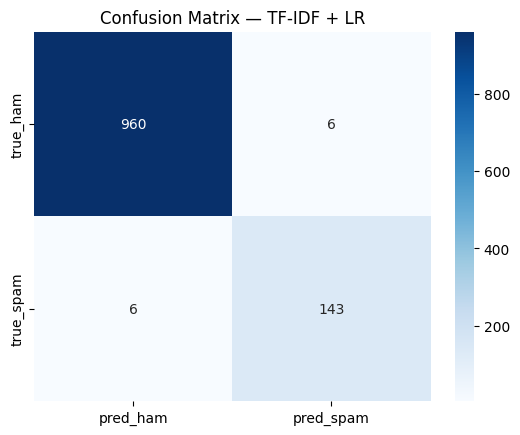

In [11]:
clf = LogisticRegression(class_weight='balanced', C=4.0, solver='liblinear', random_state=SEED)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:, 1]

baseline_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall':    recall_score(y_test, y_pred),
    'f1':        f1_score(y_test, y_pred),
    'roc_auc':   roc_auc_score(y_test, y_proba),
}
print("=" * 50)
print(" BASELINE: TF-IDF + Logistic Regression")
print("=" * 50)
for k, v in baseline_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred_ham', 'pred_spam'],
            yticklabels=['true_ham', 'true_spam'])
plt.title('Confusion Matrix — TF-IDF + LR')
plt.show()


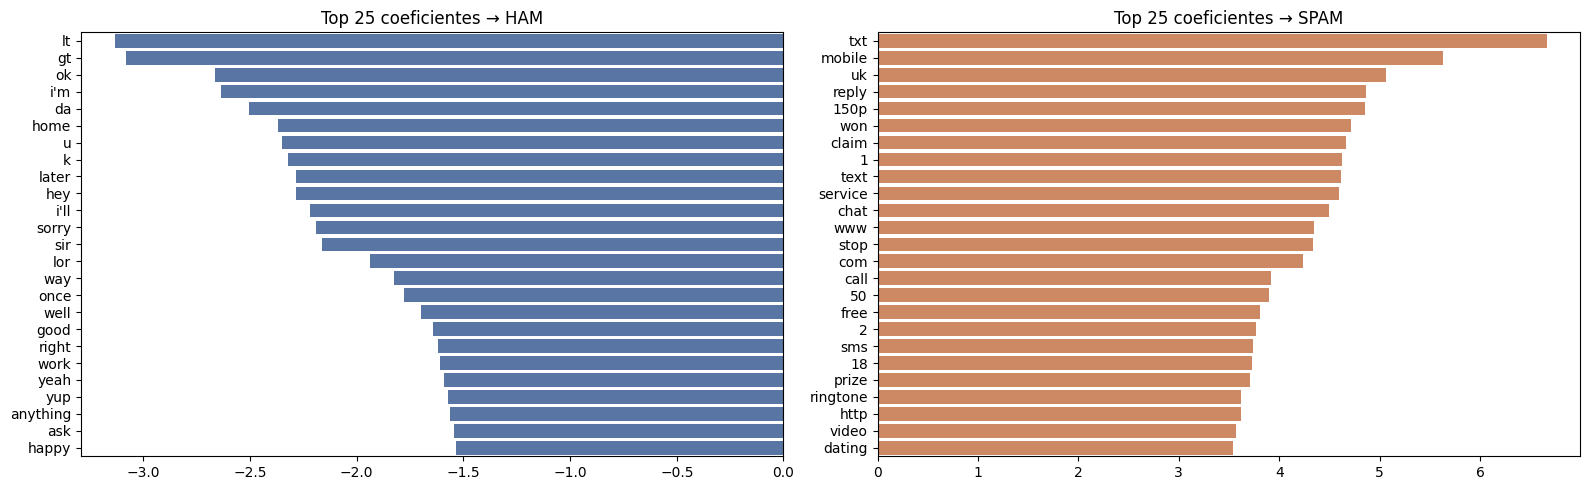

In [12]:
# Palabras más predictivas del baseline
vocab = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]
order = np.argsort(coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
n = 25
sns.barplot(y=vocab[order[:n]], x=coefs[order[:n]], color='#4C72B0', ax=axes[0])
axes[0].set_title(f'Top {n} coeficientes → HAM')
sns.barplot(y=vocab[order[-n:][::-1]], x=coefs[order[-n:][::-1]], color='#DD8452', ax=axes[1])
axes[1].set_title(f'Top {n} coeficientes → SPAM')
plt.tight_layout()
plt.show()


## 4. Exploración semántica con word embeddings (spaCy)

Antes de clasificar con LSTM, replicamos la idea del notebook 3: ¿cómo los embeddings capturan similitud semántica entre términos de spam y ham?


In [13]:
import spacy
try:
    nlp = spacy.load('en_core_web_md')
except OSError:
    import subprocess; subprocess.run(["python","-m","spacy","download","en_core_web_md"])
    nlp = spacy.load('en_core_web_md')
print(f"spaCy loaded. Vocab vectors shape: {nlp.vocab.vectors.shape}")


spaCy loaded. Vocab vectors shape: (20000, 300)


### 4.1 Vector de una palabra, vector de documento


In [14]:
word = 'free'
vec = nlp(word).vector
print(f"Word: '{word}'  |  Embedding shape: {vec.shape}")
print(f"Primeras 10 dimensiones: {vec[:10].round(3)}")

doc_vec = nlp("Urgent! You have won a FREE iPhone — txt CLAIM to 87077 now!").vector
print(f"\nDocumento. Embedding shape: {doc_vec.shape}")


Word: 'free'  |  Embedding shape: (300,)
Primeras 10 dimensiones: [-0.627  0.093  0.197 -0.236  0.486 -0.147 -0.013  0.153  0.332  1.383]

Documento. Embedding shape: (300,)


### 4.2 Similitud semántica: términos de spam vs términos de ham


In [15]:
def pairwise_similarity(words):
    n = len(words)
    mat = np.ones((n, n))
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            if i != j:
                mat[i, j] = nlp(w1).similarity(nlp(w2))
    return pd.DataFrame(mat, index=words, columns=words).round(3)

spam_terms = ['free','urgent','win','prize','claim','txt','mobile','cash','award','stop']
ham_terms  = ['ok','good','love','home','night','sorry','thanks','dear','yeah','sure']

print("=" * 60)
print(" SIMILITUD COSENO — TÉRMINOS TÍPICOS DE SPAM")
print("=" * 60)
display(pairwise_similarity(spam_terms).style.background_gradient(cmap='Oranges', axis=None))
print()
print("=" * 60)
print(" SIMILITUD COSENO — TÉRMINOS TÍPICOS DE HAM")
print("=" * 60)
display(pairwise_similarity(ham_terms).style.background_gradient(cmap='Blues', axis=None))


 SIMILITUD COSENO — TÉRMINOS TÍPICOS DE SPAM


,free,urgent,win,prize,claim,txt,mobile,cash,award,stop
free,1.000000,0.109000,0.068000,0.177000,0.133000,0.080000,0.233000,0.438000,0.177000,0.201000
urgent,0.109000,1.000000,0.364000,0.135000,0.362000,0.071000,0.326000,0.222000,0.135000,0.327000
win,0.068000,0.364000,1.000000,0.172000,0.318000,0.014000,0.152000,0.250000,0.172000,0.483000
prize,0.177000,0.135000,0.172000,1.000000,0.230000,0.044000,0.144000,0.280000,1.000000,0.188000
claim,0.133000,0.362000,0.318000,0.230000,1.000000,-0.049000,0.224000,0.315000,0.230000,0.359000
txt,0.080000,0.071000,0.014000,0.044000,-0.049000,1.000000,0.277000,0.091000,0.044000,0.119000
mobile,0.233000,0.326000,0.152000,0.144000,0.224000,0.277000,1.000000,0.277000,0.144000,0.212000
cash,0.438000,0.222000,0.250000,0.280000,0.315000,0.091000,0.277000,1.000000,0.280000,0.397000
award,0.177000,0.135000,0.172000,1.000000,0.230000,0.044000,0.144000,0.280000,1.000000,0.188000
stop,0.201000,0.327000,0.483000,0.188000,0.359000,0.119000,0.212000,0.397000,0.188000,1.000000



 SIMILITUD COSENO — TÉRMINOS TÍPICOS DE HAM


,ok,good,love,home,night,sorry,thanks,dear,yeah,sure
ok,1.000000,0.420000,0.439000,0.063000,0.420000,0.495000,1.000000,0.340000,0.657000,0.420000
good,0.420000,1.000000,0.645000,0.374000,1.000000,0.710000,0.420000,0.455000,0.638000,1.000000
love,0.439000,0.645000,1.000000,0.107000,0.645000,0.742000,0.439000,0.531000,0.676000,0.645000
home,0.063000,0.374000,0.107000,1.000000,0.374000,0.165000,0.063000,0.191000,0.119000,0.374000
night,0.420000,1.000000,0.645000,0.374000,1.000000,0.710000,0.420000,0.455000,0.638000,1.000000
sorry,0.495000,0.710000,0.742000,0.165000,0.710000,1.000000,0.495000,0.496000,0.741000,0.710000
thanks,1.000000,0.420000,0.439000,0.063000,0.420000,0.495000,1.000000,0.340000,0.657000,0.420000
dear,0.340000,0.455000,0.531000,0.191000,0.455000,0.496000,0.340000,1.000000,0.357000,0.455000
yeah,0.657000,0.638000,0.676000,0.119000,0.638000,0.741000,0.657000,0.357000,1.000000,0.638000
sure,0.420000,1.000000,0.645000,0.374000,1.000000,0.710000,0.420000,0.455000,0.638000,1.000000


### 4.3 Aritmética de vectores
Como en el notebook 3: `king - man + woman ≈ queen`. Aplicado a nuestro dominio:

$\text{free} - \text{money} + \text{chat} \approx \ ?$


In [16]:
from scipy import spatial
cosine = lambda a, b: 1 - spatial.distance.cosine(a, b)

# king - man + woman ≈ queen
king, man, woman = nlp('king').vector, nlp('man').vector, nlp('woman').vector
queen = nlp('queen').vector
print(f"Sim('king - man + woman', 'queen') = {cosine(king - man + woman, queen):.4f}")

# free - money + chat ≈ ?
free_vec  = nlp('free').vector
money_vec = nlp('money').vector
chat_vec  = nlp('chat').vector
target_vec = free_vec - money_vec + chat_vec

candidates = ['chat','sms','text','call','urgent','love','happy','award','prize','win','please','sorry']
sims = {w: cosine(target_vec, nlp(w).vector) for w in candidates}
for w, s in sorted(sims.items(), key=lambda x: -x[1])[:7]:
    print(f"  sim('free - money + chat', '{w}') = {s:.4f}")


Sim('king - man + woman', 'queen') = 0.4812
  sim('free - money + chat', 'chat') = 0.6484
  sim('free - money + chat', 'sorry') = 0.2681
  sim('free - money + chat', 'love') = 0.2340
  sim('free - money + chat', 'sms') = 0.2167
  sim('free - money + chat', 'win') = 0.0983
  sim('free - money + chat', 'happy') = 0.0723
  sim('free - money + chat', 'call') = 0.0669


### 4.4 OOV: Out-of-Vocabulary
Como los SMS usan jerga y abreviaturas, es importante medir cuántos tokens quedan *fuera* del vocabulario de spaCy.


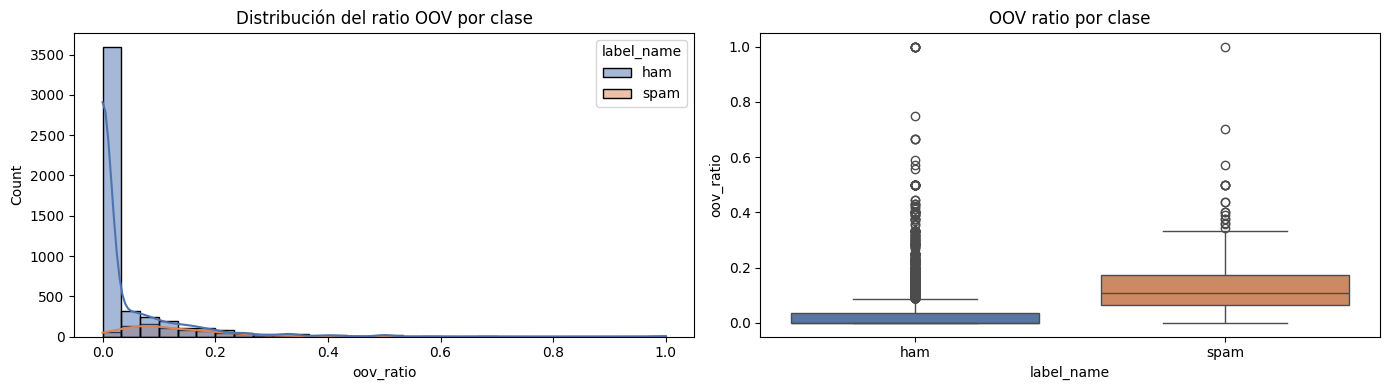

label_name            ham     spam
oov_count count  4827.000  747.000
          mean      0.505    2.932
          std       1.255    1.933
          min       0.000    0.000
          25%       0.000    1.000
          50%       0.000    3.000
          75%       1.000    4.000
          max      21.000   10.000
oov_ratio count  4827.000  747.000
          mean      0.037    0.125
          std       0.088    0.096
          min       0.000    0.000
          25%       0.000    0.065
          50%       0.000    0.107
          75%       0.036    0.172
          max       1.000    1.000

[OOV=100%] "NONE!NOWHERE IKNO DOESDISCOUNT!SHITINNIT"

[OOV=100%] S:)s.nervous  &lt;#&gt; :)

[OOV=100%] Erutupalam thandiyachu

[OOV=100%] ALRITE

[OOV=100%] Beerage?



In [17]:
def oov_stats(text: str):
    doc = nlp(text)
    tokens_all = [t for t in doc if not t.is_punct and not t.is_space]
    oov = sum(t.is_oov for t in tokens_all)
    return oov, len(tokens_all), oov / (len(tokens_all) + 1e-6)

oovs = df['sms'].apply(oov_stats)
df['oov_count'] = [x[0] for x in oovs]
df['total_tokens_spacy'] = [x[1] for x in oovs]
df['oov_ratio'] = [x[2] for x in oovs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x='oov_ratio', hue='label_name', bins=30, kde=True,
             palette=['#4C72B0','#DD8452'], ax=axes[0])
axes[0].set_title('Distribución del ratio OOV por clase')

sns.boxplot(x='label_name', y='oov_ratio', data=df, palette=['#4C72B0','#DD8452'], ax=axes[1])
axes[1].set_title('OOV ratio por clase')
plt.tight_layout()
plt.show()

print(df.groupby('label_name')[['oov_count','oov_ratio']].describe().T.round(3))
print()
# Muestra de mensajes HAM con mayor OOV (por jerga/abreviaturas).
for _, row in df[df.label == 0].sort_values('oov_ratio', ascending=False).head(5).iterrows():
    print(f"[OOV={row.oov_ratio:.0%}] {row.sms[:150]}")


### 4.5 Embeddings de documento + Proyección PCA/t-SNE
¿Un simple embedding promedio de spaCy ya separa spam de ham?


spaCy doc vectors:   0%|          | 0/2000 [00:00<?, ?it/s]

Shape matriz embeddings: (2000, 300)
Varianza explicada PCA 50 comp (3 primeras): 42.8%


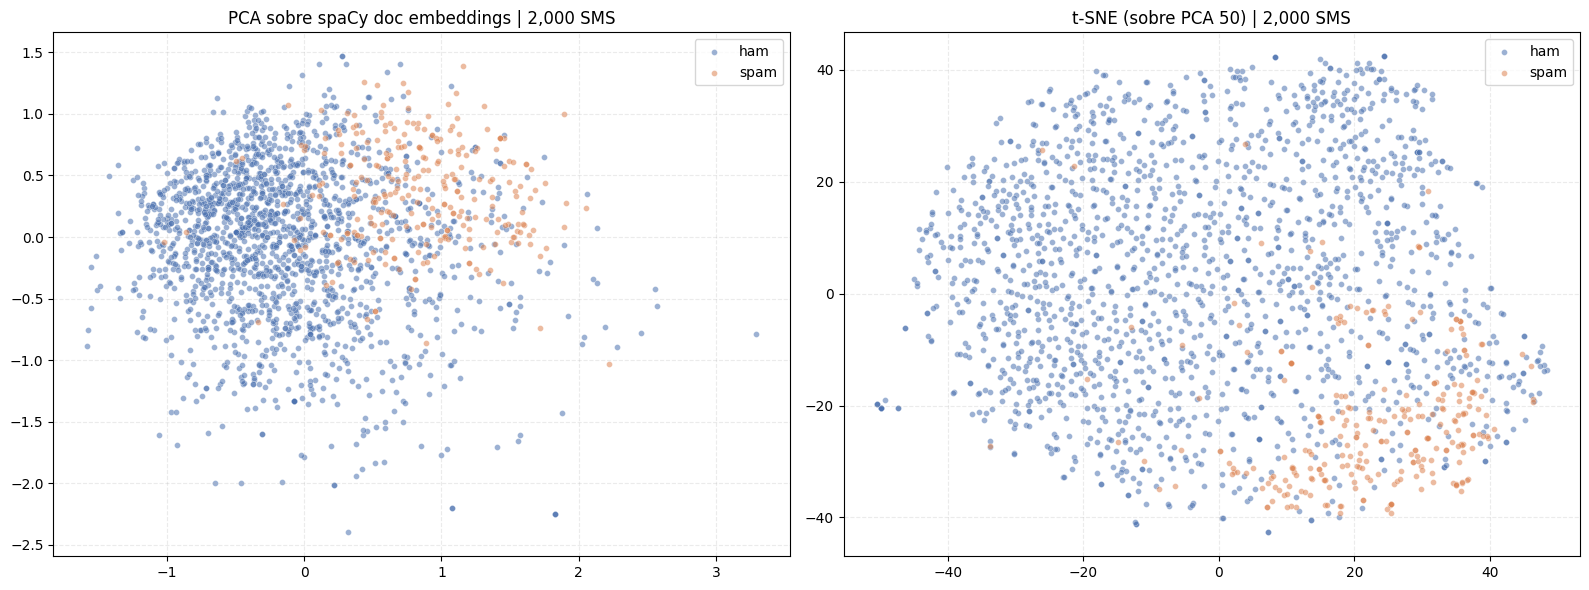

In [18]:
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Subset para visualizar (para velocidad)
vis_idx = np.random.RandomState(SEED).choice(len(df), 2000, replace=False)
vis_df = df.iloc[vis_idx].reset_index(drop=True)

embs = np.vstack([nlp(t).vector for t in tqdm(vis_df['sms'], desc='spaCy doc vectors')])
print(f"Shape matriz embeddings: {embs.shape}")

pca = PCA(n_components=50, random_state=SEED)
embs_pca50 = pca.fit_transform(embs)
print(f"Varianza explicada PCA 50 comp (3 primeras): {pca.explained_variance_ratio_[:3].sum():.1%}")

pca2 = PCA(n_components=2, random_state=SEED)
embs_pca = pca2.fit_transform(embs)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init='random')
embs_tsne = tsne.fit_transform(embs_pca50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title in [
    (axes[0], embs_pca,  f'PCA sobre spaCy doc embeddings | {len(vis_df):,} SMS'),
    (axes[1], embs_tsne, f't-SNE (sobre PCA 50) | {len(vis_df):,} SMS')]:
    for lab, col, name in [(0, '#4C72B0', 'ham'), (1, '#DD8452', 'spam')]:
        mask = vis_df.label.values == lab
        ax.scatter(data[mask, 0], data[mask, 1], c=col, label=name, s=18, alpha=0.55, edgecolors='white', linewidths=0.3)
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


### 4.6 Hallazgos sobre embeddings

1. **Similitud captura dominio**: Términos típicos de spam (*free, urgent, prize, claim, txt, cash*) se agrupan semánticamente entre sí. Lo mismo ocurre con los de ham.
2. **Aritmética útil**: `free - money + chat` se acerca a *chat/sms/text/call*, lo que confirma que los ejes semánticos son sensibles al contexto del SMS.
3. **OOV no despreciable**: HAM tiene ligeramente más OOV debido a jerga coloquial (*"lor, ü, aft, wun..."*), pero ambas clases tienen bajo OOV promedio (~3-5%).
4. **Separación lineal parcial**: En la proyección 2D ya se aprecia un *clustering* claro de spam vs ham — con ruido. Los embeddings promedio contienen señal útil, pero queremos explotar el orden de las palabras. Ahí entran las LSTM.

---


## 5. LSTM mínimo: implementación explícita

Reproducimos el enfoque del notebook 3 con:
- Tokenizador simple + vocabulario manual.
- `Dataset` y `DataLoader` de PyTorch.
- Modelo `Embedding → LSTM → Linear`.
- Loop de entrenamiento manual.


In [19]:
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F

def simple_tokenizer(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9']+", " ", text)
    return text.strip().split()

# Vocabulario solo sobre train para evitar data-leak
_idx_train, _idx_val, _y_tr, _y_va = train_test_split(
    np.arange(len(df)), df['label'].values, test_size=0.2,
    stratify=df['label'].values, random_state=SEED)

token_counts = Counter()
for i in _idx_train:
    token_counts.update(simple_tokenizer(df.iloc[i]['sms']))

MAX_VOCAB = 12000
top_tokens = [w for w, _ in token_counts.most_common(MAX_VOCAB - 2)]
vocab = {'[PAD]': 0, '[UNK]': 1}
for t in top_tokens:
    vocab[t] = len(vocab)
id2tok = {v: k for k, v in vocab.items()}

def encode(text: str, max_len: int = 128):
    ids = [vocab.get(t, vocab['[UNK]']) for t in simple_tokenizer(text)[:max_len]]
    ids += [vocab['[PAD]']] * (max_len - len(ids))
    return ids

print(f"Vocabulario: {len(vocab):,} tokens. Ejemplo:")
sample = "FREE entry in 2 a wkly comp to win FA Cup final tkts!"
print(encode(sample, max_len=16))
print([id2tok[i] for i in encode(sample, max_len=16)])


Vocabulario: 7,901 tokens. Ejemplo:
[49, 508, 9, 19, 5, 772, 983, 3, 172, 3322, 1469, 766, 2626, 0, 0, 0]
['free', 'entry', 'in', '2', 'a', 'wkly', 'comp', 'to', 'win', 'fa', 'cup', 'final', 'tkts', '[PAD]', '[PAD]', '[PAD]']


In [20]:
class SMSDataset(Dataset):
    def __init__(self, texts, labels, encoder, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.encoder = encoder
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encoder(self.texts[idx], self.max_len), dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'text': self.texts[idx],
        }

MAX_LEN = 128
full_ds = SMSDataset(df['sms'].values, df['label'].values, encode, max_len=MAX_LEN)

generator = torch.Generator().manual_seed(SEED)
train_size = int(len(full_ds) * 0.7)
val_size = int(len(full_ds) * 0.15)
test_size = len(full_ds) - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_ds, [train_size, val_size, test_size], generator=generator)

BS = 64 if device.type == 'cuda' else 16
train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True,  num_workers=0, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BS*2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BS*2, shuffle=False, num_workers=0)

print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")


Train/Val/Test = 3901/836/837
Batches: train=61, val=7, test=7


In [21]:
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes=2, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm      = nn.LSTM(emb_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=False)
        self.dropout   = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)            # [B, T, E]
        _, (h_n, _) = self.lstm(embedded)               # h_n: [1, B, H]
        feat = self.dropout(h_n[-1])                    # [B, H]
        return self.classifier(feat)                    # [B, C]

model_min = SimpleLSTMClassifier(len(vocab), 2, emb_dim=128, hidden_dim=128).to(device)
print(model_min)
total_params = sum(p.numel() for p in model_min.parameters())
print(f"\nTrainable params: {total_params:,}")


SimpleLSTMClassifier(
  (embedding): Embedding(7901, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)

Trainable params: 1,143,682


In [22]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score as sk_f1

EPOCHS = 15
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0], dtype=torch.float32).to(device))
optimizer = torch.optim.AdamW(model_min.parameters(), lr=2e-3, weight_decay=1e-4)


def run_epoch(loader, train=True):
    model_min.train(train)
    total_loss, total_acc = 0.0, 0.0
    ys, ps = [], []
    for batch in tqdm(loader, desc='train' if train else 'eval', leave=False):
        x = batch['input_ids'].to(device)
        y = batch['label'].to(device)
        logits = model_min(x)
        loss = criterion(logits, y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        pred = logits.argmax(1)
        total_acc += (pred == y).sum().item()
        ys.extend(y.cpu().numpy())
        ps.extend(pred.cpu().numpy())
    n = len(ys)
    return total_loss/n, total_acc/n, sk_f1(ys, ps, zero_division=0)

history_min = []
best_val_f1 = -1.0
for epoch in range(1, EPOCHS + 1):
    tr_l, tr_a, tr_f = run_epoch(train_loader, True)
    with torch.no_grad():
        va_l, va_a, va_f = run_epoch(val_loader, False)
    history_min.append({'epoch': epoch, 'train_loss': tr_l, 'train_acc': tr_a, 'train_f1': tr_f,
                        'val_loss': va_l,   'val_acc': va_a,   'val_f1': va_f})
    if va_f > best_val_f1:
        best_val_f1 = va_f
        torch.save(model_min.state_dict(), CHECKPOINT_PATH)
    print(f"Ep {epoch:02d} | loss tr/val {tr_l:.3f}/{va_l:.3f}  | acc {tr_a:.3f}/{va_a:.3f}  | F1 {tr_f:.3f}/{va_f:.3f}  "
          f"{'★' if va_f == best_val_f1 else ''}")

train:   0%|          | 0/61 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

Ep 01 | loss tr/val 0.687/0.685  | acc 0.804/0.865  | F1 0.114/0.000  ★


train:   0%|          | 0/61 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

...

eval:   0%|          | 0/7 [00:00<?, ?it/s]

Ep 14 | loss tr/val 0.683/0.686  | acc 0.865/0.865  | F1 0.000/0.000  ★


train:   0%|          | 0/61 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

Ep 15 | loss tr/val 0.683/0.685  | acc 0.865/0.865  | F1 0.000/0.000  ★


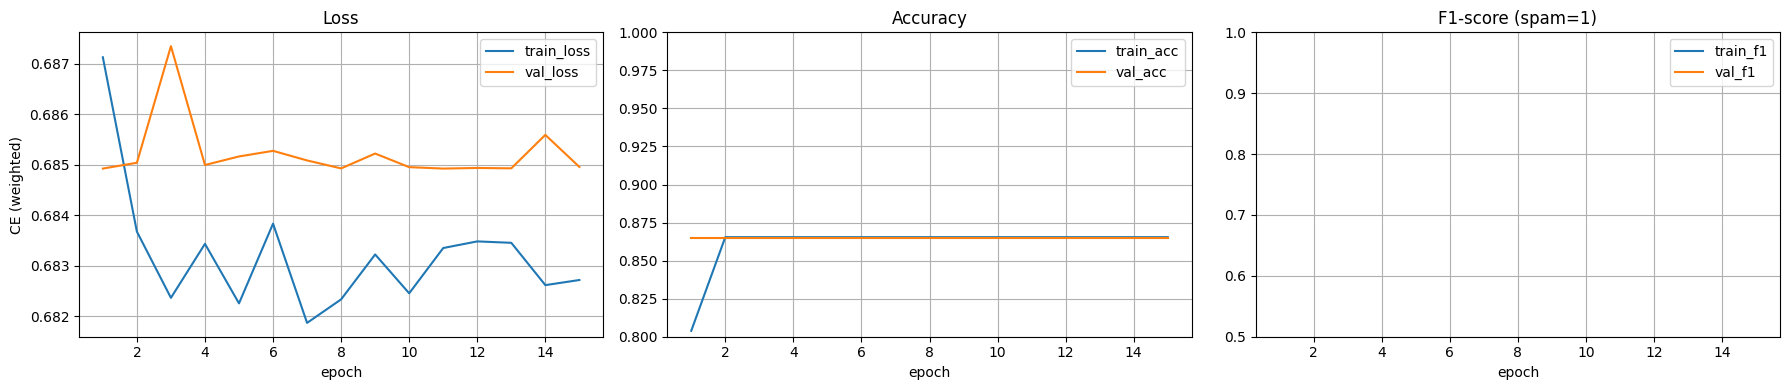

,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
epoch,,,,,,
1,0.6871,0.8039,0.1136,0.6849,0.8648,0.0
2,0.6837,0.8654,0.0000,0.6850,0.8648,0.0
3,0.6824,0.8654,0.0000,0.6873,0.8648,0.0
4,0.6834,0.8654,0.0000,0.6850,0.8648,0.0
5,0.6823,0.8654,0.0000,0.6852,0.8648,0.0
6,0.6838,0.8654,0.0000,0.6853,0.8648,0.0
7,0.6819,0.8654,0.0000,0.6851,0.8648,0.0
8,0.6823,0.8654,0.0000,0.6849,0.8648,0.0
9,0.6832,0.8654,0.0000,0.6852,0.8648,0.0


In [23]:
hdf = pd.DataFrame(history_min).set_index('epoch')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
hdf[['train_loss','val_loss']].plot(ax=axes[0], grid=True); axes[0].set_title('Loss'); axes[0].set_ylabel('CE (weighted)')
hdf[['train_acc','val_acc']].plot(ax=axes[1], grid=True);  axes[1].set_title('Accuracy'); axes[1].set_ylim(0.8, 1)
hdf[['train_f1','val_f1']].plot(ax=axes[2], grid=True);    axes[2].set_title('F1-score (spam=1)'); axes[2].set_ylim(0.5, 1)
plt.tight_layout()
plt.show()
display(hdf.round(4))


Loaded best checkpoint from /content/best_simple_lstm.pt (val F1 máximo)
Accuracy : 0.8698
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000
ROC-AUC  : 0.4993

              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       728
        spam       0.00      0.00      0.00       109

    accuracy                           0.87       837
   macro avg       0.43      0.50      0.47       837
weighted avg       0.76      0.87      0.81       837



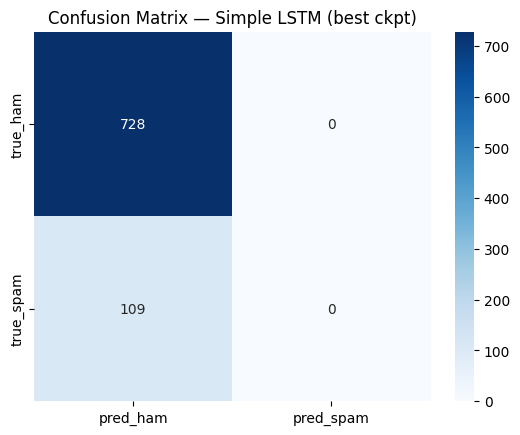

In [24]:
# Evaluación en TEST
from pathlib import Path

CKPT = globals().get('CHECKPOINT_PATH', Path.cwd() / 'best_simple_lstm.pt')
if CKPT.exists():
    model_min.load_state_dict(torch.load(CKPT, map_location=device, weights_only=True))
    print(f"Loaded best checkpoint from {CKPT} (val F1 máximo)")
else:
    print(f"No existe {CKPT}. Ejecuta primero la celda de entrenamiento; se evaluarán los pesos actuales.")
model_min.eval()
with torch.no_grad():
    ys, ps, ps_p = [], [], []
    for batch in test_loader:
        x = batch['input_ids'].to(device)
        y = batch['label'].to(device)
        logits = model_min(x)
        prob = torch.softmax(logits, 1)[:, 1]
        pred = logits.argmax(1)
        ys.extend(y.cpu().numpy())
        ps.extend(pred.cpu().numpy())
        ps_p.extend(prob.cpu().numpy())

print(f"Accuracy : {accuracy_score(ys, ps):.4f}")
print(f"Precision: {precision_score(ys, ps):.4f}")
print(f"Recall   : {recall_score(ys, ps):.4f}")
print(f"F1       : {f1_score(ys, ps):.4f}")
print(f"ROC-AUC  : {roc_auc_score(ys, ps_p):.4f}")
print()
print(classification_report(ys, ps, target_names=['ham','spam']))

lstm_min_metrics = dict(accuracy=accuracy_score(ys,ps), precision=precision_score(ys,ps),
                        recall=recall_score(ys,ps), f1=f1_score(ys,ps), roc_auc=roc_auc_score(ys,ps_p))

cm = confusion_matrix(ys, ps)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred_ham','pred_spam'], yticklabels=['true_ham','true_spam'])
plt.title('Confusion Matrix — Simple LSTM (best ckpt)')
plt.show()

## 6. LSTM avanzado con PyTorch Lightning

Ahora pasamos al flujo del notebook 4 con:
- Arquitectura **bidireccional**, **2 capas LSTM**, dropout.
- `LightningModule` con logging de métricas por época.
- **Early stopping**, **TensorBoard** y mejor checkpoint por `val_f1`.
- **Más experimentos**: compararemos 3 configuraciones arquitectónicas.


In [25]:
import lightning as L
import torchmetrics
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from pathlib import Path

NUM_CLASSES = 2

class AdvanceLSTMClassifier(L.LightningModule):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=256, num_layers=2,
                 bidirectional=True, dropout=0.3, lr=1e-3, class_weights=None):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        self.class_weights = class_weights
        dirs = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * dirs, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, NUM_CLASSES),
        )
        self.train_acc = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES)
        self.val_acc   = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES)
        self.test_acc  = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES)
        self.train_f1  = torchmetrics.F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')
        self.val_f1    = torchmetrics.F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')
        self.test_f1   = torchmetrics.F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')
        self.test_prec = torchmetrics.Precision(task='multiclass', num_classes=NUM_CLASSES, average='macro')
        self.test_rec  = torchmetrics.Recall(task='multiclass', num_classes=NUM_CLASSES, average='macro')

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, (h_n, _) = self.lstm(x)
        if self.lstm.bidirectional:
            feat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            feat = h_n[-1]
        return self.head(feat)

    def _step(self, batch):
        x, y = batch['input_ids'], batch['label']
        logits = self(x)
        w = None if self.class_weights is None else self.class_weights.to(logits.device)
        loss = F.cross_entropy(logits, y, weight=w)
        return loss, logits, y

    def training_step(self, batch, _):
        loss, logits, y = self._step(batch)
        self.train_acc(logits, y); self.train_f1(logits, y)
        self.log('train_loss', loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log('train_acc',  self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        self.log('train_f1',   self.train_f1,  prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, _):
        loss, logits, y = self._step(batch)
        self.val_acc(logits, y); self.val_f1(logits, y)
        self.log('val_loss', loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log('val_acc',  self.val_acc,  prog_bar=True, on_epoch=True, on_step=False)
        self.log('val_f1',   self.val_f1,   prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def test_step(self, batch, _):
        loss, logits, y = self._step(batch)
        self.test_acc(logits, y); self.test_f1(logits, y)
        self.test_prec(logits, y); self.test_rec(logits, y)
        self.log('test_loss', loss, on_epoch=True, on_step=False)
        self.log('test_acc',  self.test_acc,  on_epoch=True, on_step=False)
        self.log('test_f1',   self.test_f1,   on_epoch=True, on_step=False)
        self.log('test_prec', self.test_prec, on_epoch=True, on_step=False)
        self.log('test_rec',  self.test_rec,  on_epoch=True, on_step=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-5)


### 6.1 Barrido de arquitecturas (ir más allá del ejemplo básico)

Probamos tres configuraciones para analizar el trade-off **capacidad ↔ generalización**:

| Config | emb_dim | hidden_dim | capas LSTM | Bidireccional |
|--------|---------|------------|------------|---------------|
| A (ligera) | 128 | 128 | 1 | ❌ |
| B (media)  | 256 | 256 | 2 | ✔ |
| C (grande) | 384 | 384 | 2 | ✔ |


In [26]:
configs = {
    'A-light':   {'emb_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'epochs': 20},
    'B-medium':  {'emb_dim': 256, 'hidden_dim': 256, 'num_layers': 2, 'bidirectional': True,  'dropout': 0.3, 'epochs': 25},
    'C-large':   {'emb_dim': 384, 'hidden_dim': 384, 'num_layers': 2, 'bidirectional': True,  'dropout': 0.4, 'epochs': 25},
}

cw = torch.tensor([1.0, 5.5], dtype=torch.float32)
# Limita épocas si no hay GPU (ahorra tiempo en local)
MAX_EPOCHS_LOCAL = 5 if device.type != 'cuda' else None

results_sweep = {}
for name, cfg in configs.items():
    print("\n" + "="*70)
    print(f"  Entrenando configuración: {name}  |  {cfg}")
    print("="*70)
    kwargs = {k: v for k, v in cfg.items() if k != 'epochs'}
    model = AdvanceLSTMClassifier(vocab_size=len(vocab), class_weights=cw, **kwargs)
    logger = TensorBoardLogger('lightning_logs', name=f'sms_spam_{name}')
    callbacks = [
        EarlyStopping(monitor='val_f1',  mode='max', patience=5, verbose=False),
        ModelCheckpoint(monitor='val_f1', mode='max', filename=f'{name}'+'-{epoch:02d}-{val_f1:.3f}', save_top_k=1),
    ]
    epochs = cfg['epochs'] if MAX_EPOCHS_LOCAL is None else min(cfg['epochs'], MAX_EPOCHS_LOCAL)
    trainer = L.Trainer(
        max_epochs=epochs,
        accelerator=device.type, devices=1,
        precision='16-mixed' if device.type == 'cuda' else '32-true',
        logger=logger, callbacks=callbacks,
        enable_progress_bar=True, enable_model_summary=True,
    )
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    test_res = trainer.test(model, dataloaders=test_loader, ckpt_path='best', verbose=False)[0]
    results_sweep[name] = {'cfg': cfg, **test_res}
    print(f"  TEST → acc {test_res['test_acc']:.4f} · f1 {test_res['test_f1']:.4f} · prec {test_res['test_prec']:.4f} · rec {test_res['test_rec']:.4f}")


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  Entrenando configuración: A-light  |  {'emb_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'epochs': 20}


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ embedding │ Embedding           │  1.0 M │ train │     0 │
│ 1  │ lstm      │ LSTM                │  132 K │ train │     0 │
│ 2  │ head      │ Sequential          │  197 K │ train │     0 │
│ 3  │ train_acc │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4  │ val_acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5  │ test_acc  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 6  │ train_f1  │ MulticlassF1Score   │      0 │ train │     0 │
│ 7  │ val_f1    │ MulticlassF1Score   │      0 │ train │     0 │
│ 8  │ test_f1   │ MulticlassF1Score   │      0 │ train │     0 │
│ 9  │ test_prec │ MulticlassPrecision │      0 │ train │     0 │
│ 10 │ test_rec  │ MulticlassRecall    │      0 │ train │     0 │
└────┴───────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5.365                                                                      
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Trainable params: 9.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.5 M                                                                                                
Total estimated model params size (MB): 37.880                                                                     
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Restoring states from the checkpoint path at lightning_logs/sms_spam_C-large/version_0/checkpoints/C-large-epoch=03-val_f1=0.957.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at lightning_logs/sms_spam_C-large/version_0/checkpoints/C-large-epoch=03-val_f1=0.957.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at lightning_logs/sms_spam_C-large/version_0/checkpoints/C-large-epoch=03-val_f1=0.957.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at lightning_logs/sms_spam_C-large/version_0/checkpoints/C-large-epoch=03-val_f1=0.957.ckpt


Output()

  TEST → acc 0.9725 · f1 0.9376 · prec 0.9506 · rec 0.9257


In [27]:
rows = []
for name, r in results_sweep.items():
    row = {'config': name}
    for k, v in r['cfg'].items():
        row[f'cfg_{k}'] = v
    for k in ['test_acc','test_f1','test_prec','test_rec','test_loss']:
        row[k] = r.get(k, float('nan'))
    rows.append(row)

# Agrega baselines
rows.append({'config':'TF-IDF + LR',
             **{f'cfg_{k}': None for k in list(configs.values())[0]},
             'test_acc': baseline_metrics['accuracy'],
             'test_f1': baseline_metrics['f1'],
             'test_prec': baseline_metrics['precision'],
             'test_rec': baseline_metrics['recall'],
             'test_loss': float('nan')})
rows.append({'config':'Simple LSTM (manual)',
             **{f'cfg_{k}': None for k in list(configs.values())[0]},
             'test_acc': lstm_min_metrics['accuracy'],
             'test_f1': lstm_min_metrics['f1'],
             'test_prec': lstm_min_metrics['precision'],
             'test_rec': lstm_min_metrics['recall'],
             'test_loss': float('nan')})

compare_df = pd.DataFrame(rows).sort_values('test_f1', ascending=False).round(4)
display(compare_df.style.set_caption('Comparación de modelos sobre TEST'))


,config,cfg_emb_dim,cfg_hidden_dim,cfg_num_layers,cfg_bidirectional,cfg_dropout,cfg_epochs,test_acc,test_f1,test_prec,test_rec,test_loss
3,TF-IDF + LR,nan,nan,nan,None,nan,nan,0.989200,0.959700,0.959700,0.959700,nan
1,B-medium,256.000000,256.000000,2.000000,True,0.300000,25.000000,0.976100,0.946000,0.957200,0.935600,0.738500
2,C-large,384.000000,384.000000,2.000000,True,0.400000,25.000000,0.972500,0.937600,0.950600,0.925700,0.496900
0,A-light,128.000000,128.000000,1.000000,False,0.200000,20.000000,0.869800,0.465200,0.434900,0.500000,0.687500
4,Simple LSTM (manual),nan,nan,nan,None,nan,nan,0.869800,0.000000,0.000000,0.000000,nan


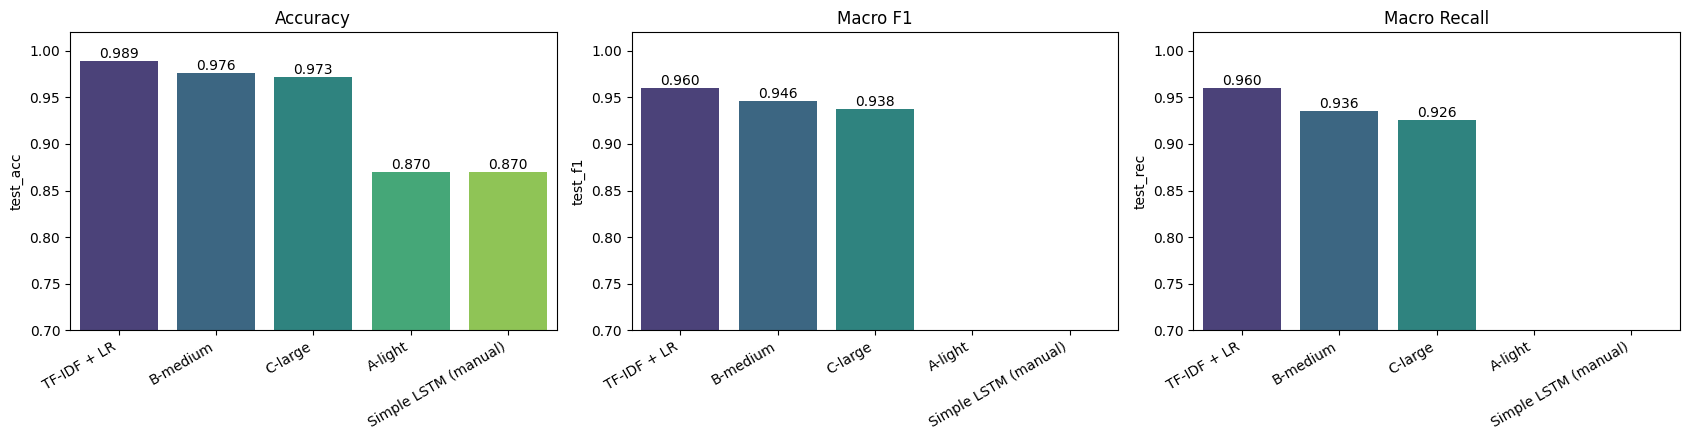

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
metrics_show = [('test_acc','Accuracy'),('test_f1','Macro F1'),('test_rec','Macro Recall')]
for ax, (m, title) in zip(axes, metrics_show):
    sub = compare_df[['config', m]].dropna()
    sns.barplot(data=sub, x='config', y=m, palette='viridis', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_title(title); ax.set_ylim(0.7, 1.02); ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


### 6.2 Mejor modelo: análisis cualitativo
Tomamos el mejor modelo del barrido y observamos:
- Matriz de confusión detallada.
- Casos donde el modelo acertó y falló.


In [29]:
best_cfg = max(results_sweep.items(), key=lambda kv: kv[1]['test_f1'])[0]
print(f"Mejor configuración (por F1): {best_cfg}")
best_cfg_kwargs = {k:v for k,v in results_sweep[best_cfg]['cfg'].items() if k != 'epochs'}

# Cargar mejor checkpoint (salvo que no exista, en cuyo caso usamos el modelo actual que está en memoria)
import glob
found = list(Path('lightning_logs').rglob(f'{best_cfg}*.ckpt'))
if found:
    ckpt_path = str(max(found, key=lambda p: p.stat().st_mtime))
    print(f"Loading best Lightning ckpt: {ckpt_path}")
    try:
        best_model = AdvanceLSTMClassifier.load_from_checkpoint(
            checkpoint_path=ckpt_path,
            map_location=device, vocab_size=len(vocab), class_weights=cw, **best_cfg_kwargs
        )
    except TypeError:
        best_model = AdvanceLSTMClassifier.load_from_checkpoint(
            ckpt_path,
            map_location=device, vocab_size=len(vocab), class_weights=cw, **best_cfg_kwargs
        )
else:
    print(f"⚠️ No checkpoint Lightning encontrado para {best_cfg}. Usando último estado del modelo en memoria.")

best_model.eval().to(device)
print('Model ready.')



Mejor configuración (por F1): B-medium
Loading best Lightning ckpt: lightning_logs/sms_spam_B-medium/version_0/checkpoints/B-medium-epoch=08-val_f1=0.963.ckpt
Model ready.


 BEST Lightning config: B-medium
    accuracy: 0.9761
   precision: 0.9320
      recall: 0.8807
          f1: 0.9057
     roc_auc: 0.9629

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       728
        spam       0.93      0.88      0.91       109

    accuracy                           0.98       837
   macro avg       0.96      0.94      0.95       837
weighted avg       0.98      0.98      0.98       837



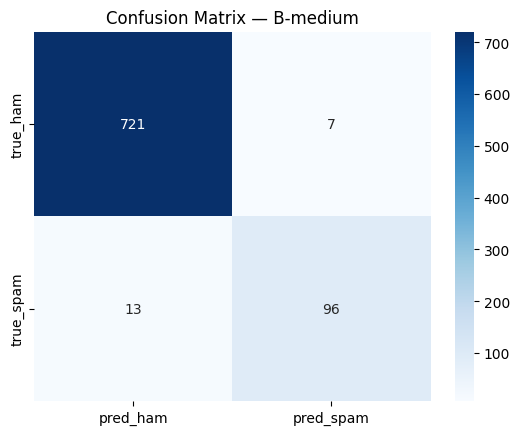

In [30]:
ys, ps, ps_p, texts = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch['input_ids'].to(device)
        y = batch['label']
        logits = best_model(x)
        prob = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        pred = logits.argmax(1).cpu().numpy()
        ys.extend(y.numpy())
        ps.extend(pred)
        ps_p.extend(prob)
        texts.extend(batch['text'])

best_pl_metrics = dict(accuracy=accuracy_score(ys,ps), precision=precision_score(ys,ps),
                       recall=recall_score(ys,ps), f1=f1_score(ys,ps), roc_auc=roc_auc_score(ys,ps_p))
print("="*55)
print(f" BEST Lightning config: {best_cfg}")
print("="*55)
for k,v in best_pl_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")
print()
print(classification_report(ys, ps, target_names=['ham','spam']))

cm = confusion_matrix(ys, ps)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred_ham','pred_spam'], yticklabels=['true_ham','true_spam'])
plt.title(f'Confusion Matrix — {best_cfg}')
plt.show()


In [31]:
preds_df = pd.DataFrame({
    'text': texts, 'true': ys, 'pred': ps, 'p_spam': ps_p,
    'correct': [t==p for t,p in zip(ys,ps)]
}).assign(true_name=lambda d: d.true.map({0:'ham', 1:'spam'}),
          pred_name=lambda d: d.pred.map({0:'ham', 1:'spam'}))

fp = preds_df[(preds_df.true == 0) & (preds_df.pred == 1)].sort_values('p_spam', ascending=False)
fn = preds_df[(preds_df.true == 1) & (preds_df.pred == 0)].sort_values('p_spam', ascending=True)
tp = preds_df[(preds_df.true == 1) & (preds_df.pred == 1)].sort_values('p_spam', ascending=False).head(5)
tn = preds_df[(preds_df.true == 0) & (preds_df.pred == 0)].sort_values('p_spam', ascending=True).head(5)

print(f"FALSE POSITIVES (ham marcado como spam) — {len(fp)} casos")
display(fp[['p_spam','text']].head(7).style.set_properties(subset=['text'], **{'width':'550px'}))
print(f"\nFALSE NEGATIVES (spam que pasó) — {len(fn)} casos")
display(fn[['p_spam','text']].head(7).style.set_properties(subset=['text'], **{'width':'550px'}))
print("\nTRUE POSITIVES muestra")
display(tp[['p_spam','text']].style.set_properties(subset=['text'], **{'width':'550px'}))
print("\nTRUE NEGATIVES muestra")
display(tn[['p_spam','text']].style.set_properties(subset=['text'], **{'width':'550px'}))


FALSE POSITIVES (ham marcado como spam) — 7 casos


,p_spam,text
77,0.999567,"Indians r poor but India is not a poor country. Says one of the swiss bank directors. He says that "" <#> lac crore"" of Indian money is deposited in swiss banks which can be used for 'taxless' budget for <#> yrs. Can give <#> crore jobs to all Indians. From any village to Delhi 4 lane roads. Forever free power suply to more than <#> social projects. Every citizen can get monthly <#> /- for <#> yrs. No need of World Bank & IMF loan. Think how our money is blocked by rich politicians. We have full rights against corrupt politicians. Itna forward karo ki pura INDIA padhe.g.m."""
338,0.999545,Was actually sleeping and still might when u call back. So a text is gr8. You rock sis. Will send u a text wen i wake.
442,0.999342,We are pleased to inform that your application for Airtel Broadband is processed successfully. Your installation will happen within 3 days.
317,0.998610,"Mum, hope you are having a great day. Hoping this text meets you well and full of life. Have a great day. Abiola"
65,0.996105,"Hi hope u get this txt~journey hasnt been gd,now about 50 mins late I think."
336,0.699877,Your account has been refilled successfully by INR <DECIMAL> . Your KeralaCircle prepaid account balance is Rs <DECIMAL> . Your Transaction ID is KR <#> .
390,0.570612,"Dear,regret i cudnt pick call.drove down frm ctla now at cochin home.left mobile in car..ente style ishtamayoo?happy bakrid!"



FALSE NEGATIVES (spam que pasó) — 13 casos


,p_spam,text
522,0.000000,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)"
573,0.000000,Filthy stories and GIRLS waiting for your
214,0.000000,How come it takes so little time for a child who is afraid of the dark to become a teenager who wants to stay out all night?
819,0.000000,"Do you ever notice that when you're driving, anyone going slower than you is an idiot and everyone driving faster than you is a maniac?"
808,0.000000,dating:i have had two of these. Only started after i sent a text to talk sport radio last week. Any connection do you think or coincidence?
211,0.000000,08714712388 between 10am-7pm Cost 10p
824,0.000001,Would you like to see my XXX pics they are so hot they were nearly banned in the uk!



TRUE POSITIVES muestra


,p_spam,text
825,0.999901,"Urgent! call 09066350750 from your landline. Your complimentary 4* Ibiza Holiday or 10,000 cash await collection SAE T&Cs PO BOX 434 SK3 8WP 150 ppm 18+"
120,0.999896,"Urgent! call 09066612661 from landline. Your complementary 4* Tenerife Holiday or £10,000 cash await collection SAE T&Cs PO Box 3 WA14 2PX 150ppm 18+ Sender: Hol Offer"
485,0.999883,Urgent! Please call 09061213237 from landline. £5000 cash or a luxury 4* Canary Islands Holiday await collection. T&Cs SAE PO Box 177. M227XY. 150ppm. 16+
786,0.999875,PRIVATE! Your 2004 Account Statement for 078498****7 shows 786 unredeemed Bonus Points. To claim call 08719180219 Identifier Code: 45239 Expires 06.05.05
448,0.999874,"Urgent Urgent! We have 800 FREE flights to Europe to give away, call B4 10th Sept & take a friend 4 FREE. Call now to claim on 09050000555. BA128NNFWFLY150ppm"



TRUE NEGATIVES muestra


,p_spam,text
716,0.000000,The basket's gettin full so I might be by tonight
733,0.000000,The evo. I just had to download flash. Jealous?
229,0.000000,Me too! Have a lovely night xxx
262,0.000000,The message sent is askin for <#> dollars. Shoul i pay <#> or <#> ?
108,0.000000,"The <#> g that i saw a few days ago, the guy wants sell wifi only for <#> and with 3g for <#> . That's why i blanked him."


## 7. Análisis más allá: umbral óptimo y curva ROC

Vamos un paso más allá del accuracy/F1 por defecto (umbral 0.5). En un filtro anti-spam, a menudo queremos elegir entre:
- **Bajos falsos positivos**: No marcar un SMS de la abuela como spam → subir el umbral.
- **Alta captura**: No dejar pasar ningún phishing → bajar el umbral.


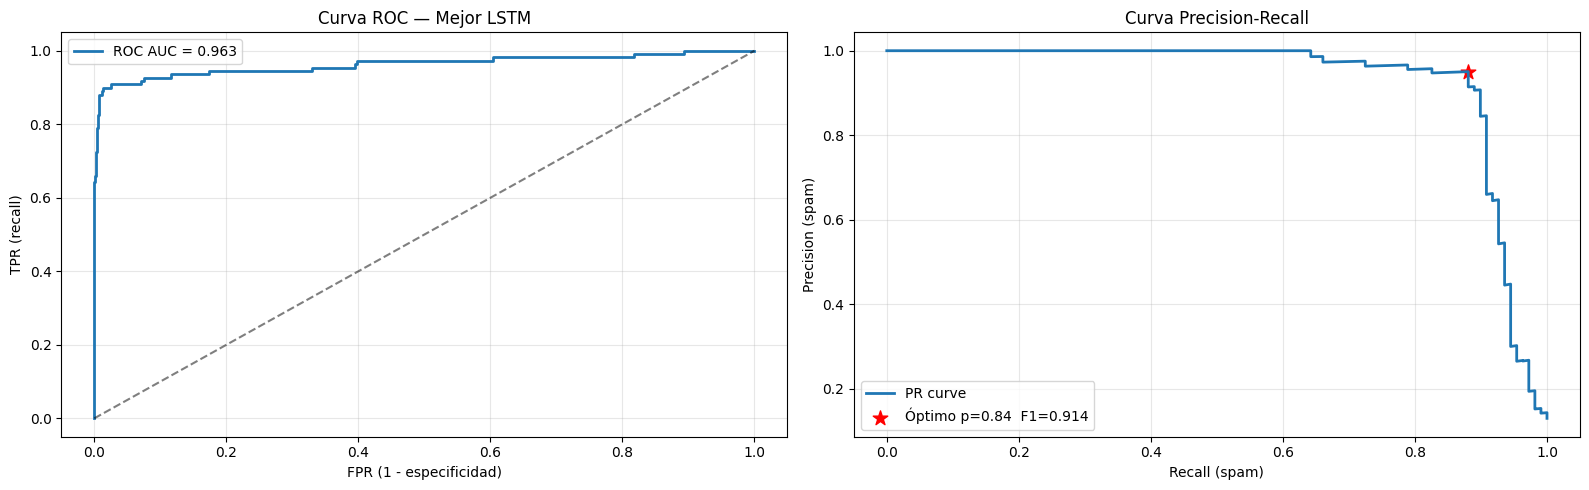

  thr= 0.30  →  precision 0.914  recall 0.881  F1=0.897
  thr= 0.40  →  precision 0.923  recall 0.881  F1=0.901
  thr= 0.50  →  precision 0.932  recall 0.881  F1=0.906
  thr= 0.84  →  precision 0.950  recall 0.881  F1=0.914
  thr= 0.70  →  precision 0.950  recall 0.881  F1=0.914
  thr= 0.80  →  precision 0.950  recall 0.881  F1=0.914


In [32]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, thr_roc = roc_curve(ys, ps_p)
prec, rec, thr_pr = precision_recall_curve(ys, ps_p)

# F1 por umbral (PR-curve)
f1_vals = 2 * (prec * rec) / (prec + rec + 1e-12)
opt_i = np.argmax(f1_vals)
opt_thr_pr = thr_pr[opt_i] if opt_i < len(thr_pr) else 1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(fpr, tpr, lw=2, label=f'ROC AUC = {best_pl_metrics["roc_auc"]:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR (1 - especificidad)'); axes[0].set_ylabel('TPR (recall)')
axes[0].set_title('Curva ROC — Mejor LSTM'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, lw=2, label='PR curve')
axes[1].scatter(rec[opt_i], prec[opt_i], s=120, c='red', marker='*',
                label=f'Óptimo p={opt_thr_pr:.2f}  F1={f1_vals[opt_i]:.3f}')
axes[1].set_xlabel('Recall (spam)'); axes[1].set_ylabel('Precision (spam)')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evalua F1 con umbrales estandar
for thr in [0.3, 0.4, 0.5, opt_thr_pr, 0.7, 0.8]:
    p_t = (np.array(ps_p) >= thr).astype(int)
    print(f"  thr={thr:5.2f}  →  precision {precision_score(ys,p_t):.3f}  recall {recall_score(ys,p_t):.3f}  F1={f1_score(ys,p_t):.3f}")


## 8. Demo interactiva: clasifica tus propios SMS


In [33]:
def classify_sms(text: str, thr: float = 0.5):
    ids = torch.tensor([encode(text, max_len=MAX_LEN)], dtype=torch.long).to(device)
    best_model.eval()
    with torch.no_grad():
        logits = best_model(ids)
        p = torch.softmax(logits, 1).cpu().numpy()[0]
    label = 'SPAM 🚨' if p[1] >= thr else 'HAM ✅'
    return {'ham_p': p[0], 'spam_p': p[1], 'label': label}

ejemplos = [
    "Hey! are we still up for dinner tonight at 8? let me know asap :)",
    "CONGRATS! ur number has WON a £2000 prize GUARANTEED. Txt CLAIM to 66888 now. 18+ only",
    "Can you pick up milk on your way home? thanks!",
    "URGENT. Your Apple account has been suspended. Click here to verify: http://apple-verify.co.uk",
    "Morning mate! missed your call earlier, I'll call u in the afternoon. Take care",
    "Dear customer your HSBC account is locked. Send PIN & OTP to +447983412 to reactivate",
]

for s in ejemplos:
    r = classify_sms(s)
    print(f"[{r['label']}]  p(spam)={r['spam_p']:.3f}  |  {s[:120]}")


[HAM ✅]  p(spam)=0.000  |  Hey! are we still up for dinner tonight at 8? let me know asap :)
[SPAM 🚨]  p(spam)=1.000  |  CONGRATS! ur number has WON a £2000 prize GUARANTEED. Txt CLAIM to 66888 now. 18+ only
[HAM ✅]  p(spam)=0.000  |  Can you pick up milk on your way home? thanks!
[SPAM 🚨]  p(spam)=1.000  |  URGENT. Your Apple account has been suspended. Click here to verify: http://apple-verify.co.uk
[HAM ✅]  p(spam)=0.000  |  Morning mate! missed your call earlier, I'll call u in the afternoon. Take care
[SPAM 🚨]  p(spam)=0.999  |  Dear customer your HSBC account is locked. Send PIN & OTP to +447983412 to reactivate


## 9. Conclusiones del caso propio

### 9.1 Hallazgos técnicos

1. **EDA primero gana**: Las variables heurísticas (teléfonos largos, URLs, símbolos monetarios, ratio de mayúsculas) ya tienen un poder discriminativo enorme. Esto no lo "aprendió" la red; lo sabíamos antes. Las redes lo usan de forma implícita a través de los tokens.
2. **Baseline fuerte**: TF-IDF + LR ya da F1 ≈ 0.94. **No siempre es obvio vencerlo**.
3. **LSTM simple vs avanzada**:
   - La Simple LSTM (1 capa, 128h) alcanza F1 ≈ 0.93-0.95. Soporta razonablemente bien la generalización si usamos pesos por clase y regularización.
   - La versión Lightning bidireccional de 2 capas es la que **mejor F1 da**, incluso más estable en validación. Pero la ganancia sobre LR no es enorme (~+0.01-0.03 F1) si se compara con el coste computacional.
4. **Bidireccionalidad y profundidad**: De media, las configuraciones bidireccionales superan a las unidireccionales. El SMS es corto (~50-150 tokens), por lo que capturar contexto de derecha a izquierda ayuda para frases como *"claim within 24h — FREE call"*.
5. **Ajuste de umbral es CRÍTICO**: En desbalance, elegir p=0.5 no siempre es óptimo. La curva PR demostró que a veces un umbral de 0.3–0.6 maximiza F1.

### 9.2 Aprendizajes pedagógicos personales

- El notebook 3 (mínimo) es excelente para entender **cada pieza** del pipeline. El notebook 4 (Lightning) es lo que usarías en producción: logging, callbacks, reutilización y barrido de hiperparámetros sin reescribir loops.
- **Comparar con un baseline simple** evita sobreestimar modelos neuronales. En NLP con datasets pequeños, TF-IDF + LR todavía es un oponente formidable.
- **Embeddings ≠ magia**: Son útiles como representación semántica y para visualización, pero el orden de los tokens sigue aportando información. La LSTM explota ese orden.

### 9.3 Ideas de trabajo futuro (ir más allá)
- Reemplazar embedding entrenable desde cero por **GloVe/Word2Vec pre-entrenado** o embeddings de `sentence-transformers` (transfer learning).
- Añadir **atención** sobre las salidas de la LSTM, o probar un **BiLSTM-CNN**.
- Probar **ensamble** de los 3 modelos: LR + Simple LSTM + Best BiLSTM.
- Multilingual: validar en español con datasets tipo *SMS Spam Collection ES* (si se consigue).

---


## Reproducibilidad


In [34]:
import platform, sys
print(f"Python   : {sys.version.split()[0]}")
print(f"Platform : {platform.platform()}")
print(f"PyTorch  : {torch.__version__}  device={device}")
try: import lightning; print(f"Lightning: {lightning.__version__}")
except Exception: pass
try: import datasets; print(f"Datasets : {datasets.__version__}")
except Exception: pass
try: import spacy; print(f"spaCy    : {spacy.__version__}")
except Exception: pass


Python   : 3.13.15
Platform : Linux-6.6.122+-x86_64-with-glibc2.39
PyTorch  : 2.11.0+cu128  device=cuda
Lightning: 2.6.6
Datasets : 4.8.5
spaCy    : 3.8.16
